# 01 — Data Validation & Experiment Health Checks

**Before analyzing any experiment, prove the experiment itself is trustworthy.**

This notebook does zero hypothesis testing on purpose. Its only job is to answer three questions that must be answered *before* anyone looks at results:

1. **Is the data what it claims to be?** (structure, missing values, plausible ranges)
2. **Did the traffic split match the design?** (Sample Ratio Mismatch check)
3. **Did randomization actually work?** (covariate balance across arms)

If any of these fail, the experiment's results are meaningless no matter how significant they look — analyzing a broken experiment precisely is just measuring a bug with confidence intervals.

**The dataset:** the Hillstrom "MineThatData" email test (2008) — a real randomized experiment on 64,000 customers of a retailer. Each customer was randomly assigned to receive a men's merchandise email, a women's merchandise email, or no email at all (control). Outcomes were tracked for two weeks: did they visit the site, did they buy (convert), and how much did they spend.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import srm_check, standardized_mean_difference, CONTROL_LABEL, TREATMENT_LABELS

sns.set_theme(style="whitegrid", palette="muted")
ASSETS = "../assets"

df = pd.read_csv("../data/raw/hillstrom.csv")
print(f"{len(df):,} rows, {df.shape[1]} columns")
df.head()

64,000 rows, 12 columns


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


## 1. Structural validation

Column meanings (pre-treatment unless noted):

| Column | Meaning |
|---|---|
| `recency` | Months since last purchase |
| `history_segment` / `history` | Dollar value spent in the past year (banded / exact) |
| `mens`, `womens` | Bought men's / women's merchandise in the past year (1/0) |
| `zip_code` | Urban / Suburban / Rural |
| `newbie` | New customer in the past 12 months (1/0) |
| `channel` | Purchase channel: Phone / Web / Multichannel |
| `segment` | **The treatment arm** (Mens E-Mail / Womens E-Mail / No E-Mail) |
| `visit` | **Outcome:** visited site within 2 weeks (1/0) |
| `conversion` | **Outcome:** purchased within 2 weeks (1/0) |
| `spend` | **Outcome:** dollars spent within 2 weeks |

We check for missing values and impossible values (negative spend, recency outside a sane range). Real experiment logs are full of these; a clean pass here is worth confirming, not assuming.

In [2]:
# Missing values: experiments with missing treatment/outcome rows are a red
# flag (data loss can be non-random and bias results toward one arm).
assert df.isna().sum().sum() == 0, "unexpected missing values"
print("Missing values: none")

# Impossible values: negative spend or recency would indicate logging bugs.
assert (df["spend"] >= 0).all() and df["recency"].between(1, 12).all()
print("Value ranges: spend >= 0, recency within 1-12 months")

# Binary outcomes really are binary.
assert set(df["visit"].unique()) <= {0, 1} and set(df["conversion"].unique()) <= {0, 1}
print("Outcome encoding: visit/conversion are strictly 0/1")

# Logical consistency: you cannot convert without visiting, and (in this
# dataset's definition) you cannot spend without converting.
assert (df.loc[df["conversion"] == 1, "visit"] == 1).all()
assert (df.loc[df["spend"] > 0, "conversion"] == 1).all()
print("Funnel consistency: conversion => visit, spend>0 => conversion")

Missing values: none
Value ranges: spend >= 0, recency within 1-12 months
Outcome encoding: visit/conversion are strictly 0/1
Funnel consistency: conversion => visit, spend>0 => conversion


## 2. Sample Ratio Mismatch (SRM) check

The design called for a 1/3 : 1/3 : 1/3 split. If the observed counts are statistically incompatible with that split, the assignment pipeline was broken (bot filtering, redirect losses, logging bugs) and **every downstream number is suspect**.

Why this matters in the real world: Microsoft reports roughly **6% of its experiments fail this check**, and their standard playbook is to discard the experiment entirely — not to "adjust" for it. The test is a chi-square goodness-of-fit against the designed split, with an alarm threshold of p < 0.001 (stricter than 0.05, because at these sample sizes the check is so sensitive that a 0.05 threshold would raise too many false alarms on healthy experiments).

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306 

chi-square = 0.203, p = 0.904  ->  PASS


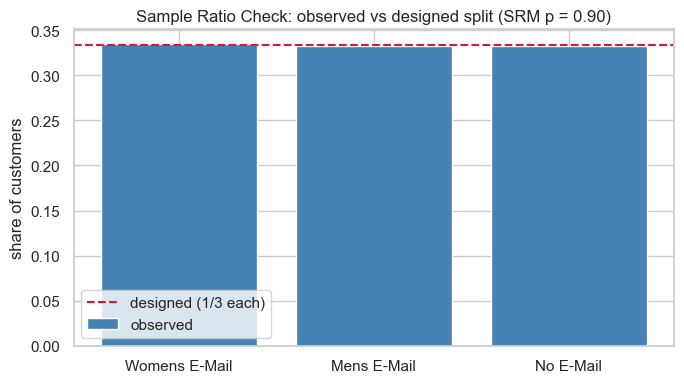

In [3]:
counts = df["segment"].value_counts()
chi2, p, verdict = srm_check(counts.to_dict())  # equal split expected by default

print(counts.to_string(), "\n")
print(f"chi-square = {chi2:.3f}, p = {p:.3f}  ->  {verdict}")

# Visualize: observed vs designed split. The bars should be near-identical.
fig, ax = plt.subplots(figsize=(7, 4))
share = counts / counts.sum()
ax.bar(share.index, share.values, color="steelblue", label="observed")
ax.axhline(1/3, color="crimson", ls="--", label="designed (1/3 each)")
ax.set_ylabel("share of customers")
ax.set_title(f"Sample Ratio Check: observed vs designed split (SRM p = {p:.2f})")
ax.legend()
plt.tight_layout()
plt.savefig(f"{ASSETS}/srm_check.png", dpi=150)
plt.show()

## 3. Covariate balance: did randomization work?

Randomization's entire purpose is to make the three groups statistically identical *before* treatment — same mix of recent buyers, big spenders, new customers, and so on. If it worked, any post-treatment difference in outcomes can only be caused by the emails (or chance, which our tests quantify).

Two deliberate methodology choices:

- **We compare only pre-treatment variables.** Outcomes (`visit`, `conversion`, `spend`) *should* differ between arms if the email works — that's the treatment effect, not imbalance.
- **We use standardized mean differences (SMD), not t-tests.** With 21,000+ customers per arm, a t-test flags differences that are statistically detectable but practically zero (e.g. $1 difference in average history). SMD measures the *size* of the imbalance in standard-deviation units; the standard threshold from the causal-inference literature is |SMD| < 0.10.

covariate  worst_abs_SMD  balanced
  recency       0.006832      True
  history       0.007613      True
     mens       0.008631      True
   womens       0.007589      True
   newbie       0.003449      True


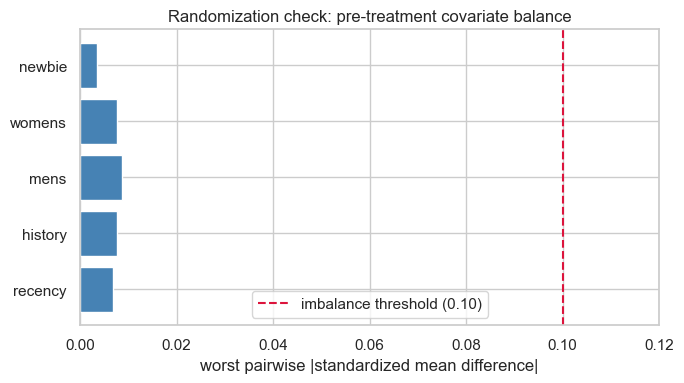

In [4]:
PRE_TREATMENT_NUMERIC = ["recency", "history", "mens", "womens", "newbie"]
arms = [CONTROL_LABEL] + TREATMENT_LABELS

# Worst pairwise |SMD| per covariate across the three arms.
rows = []
for col in PRE_TREATMENT_NUMERIC:
    worst = 0.0
    for i in range(len(arms)):
        for j in range(i + 1, len(arms)):
            a = df.loc[df["segment"] == arms[i], col].to_numpy(dtype=float)
            b = df.loc[df["segment"] == arms[j], col].to_numpy(dtype=float)
            worst = max(worst, abs(standardized_mean_difference(a, b)))
    rows.append({"covariate": col, "worst_abs_SMD": worst, "balanced": worst < 0.10})

balance = pd.DataFrame(rows)
print(balance.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(balance["covariate"], balance["worst_abs_SMD"], color="steelblue")
ax.axvline(0.10, color="crimson", ls="--", label="imbalance threshold (0.10)")
ax.set_xlabel("worst pairwise |standardized mean difference|")
ax.set_title("Randomization check: pre-treatment covariate balance")
ax.set_xlim(0, 0.12)
ax.legend()
plt.tight_layout()
plt.savefig(f"{ASSETS}/covariate_balance.png", dpi=150)
plt.show()

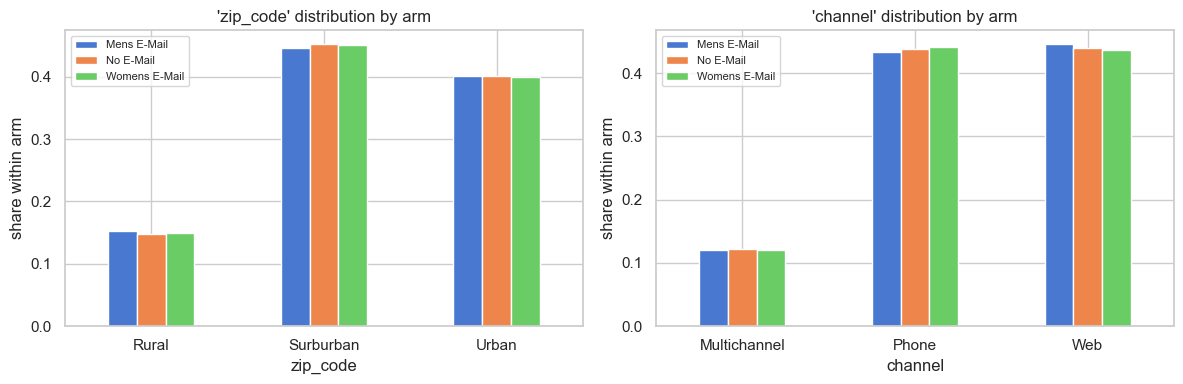

In [5]:
# Categorical covariates (zip_code, channel): compare the distribution of
# categories across arms. If randomization worked, the three bars in each
# category group should be nearly identical heights.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["zip_code", "channel"]):
    shares = df.groupby("segment")[col].value_counts(normalize=True).unstack()
    shares.T.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(f"'{col}' distribution by arm")
    ax.set_ylabel("share within arm")
    ax.legend(title=None, fontsize=8)
plt.tight_layout()
plt.savefig(f"{ASSETS}/categorical_balance.png", dpi=150)
plt.show()

## 4. Know your outcome distributions (before testing them)

This step decides *which statistical tests are appropriate* in notebook 03:

- `visit` and `conversion` are binary with low base rates → **two-proportion z-tests** are appropriate at this sample size.
- `spend` is **zero-inflated and right-skewed**: ~99% of customers spent $0, and the buyers who did spend range up to ~$500. Skew like this is the classic reason to distrust plain t-tests — so in notebook 03 we run **Welch's t-test *and* a bootstrap** and show they agree (agreement is itself evidence the parametric result is safe at n≈21k per arm).

                   n  visit_rate  conversion_rate  avg_spend  share_zero_spend
segment                                                                       
Mens E-Mail    21307      0.1828           0.0125     1.4226            0.9875
No E-Mail      21306      0.1062           0.0057     0.6528            0.9943
Womens E-Mail  21387      0.1514           0.0088     1.0772            0.9912


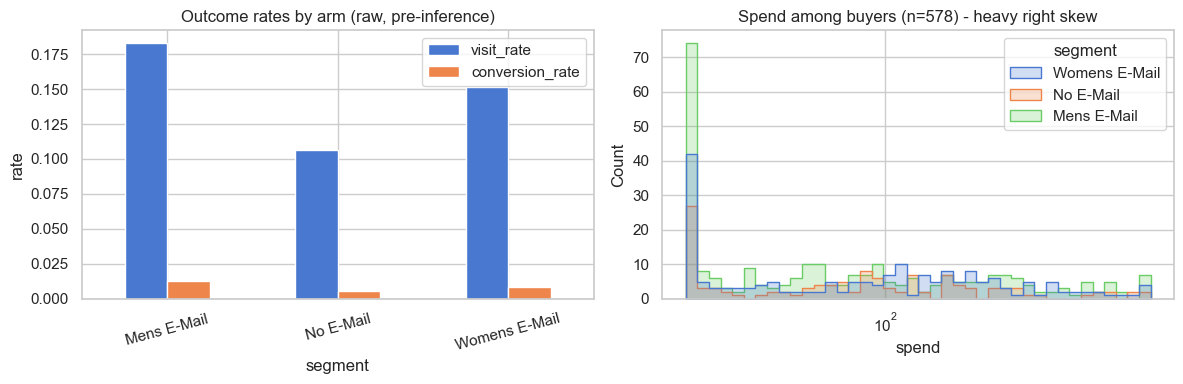

In [6]:
summary = df.groupby("segment").agg(
    n=("segment", "size"),
    visit_rate=("visit", "mean"),
    conversion_rate=("conversion", "mean"),
    avg_spend=("spend", "mean"),
    share_zero_spend=("spend", lambda s: (s == 0).mean()),
).round(4)
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw outcome rates by arm - the "eyeball" version of the result.
summary[["visit_rate", "conversion_rate"]].plot(kind="bar", ax=axes[0], rot=15)
axes[0].set_title("Outcome rates by arm (raw, pre-inference)")
axes[0].set_ylabel("rate")

# Right: spend distribution among BUYERS only (log scale), showing the skew
# that motivates the bootstrap. Plotting all customers would just show a
# spike at zero and hide the shape.
buyers = df[df["spend"] > 0]
sns.histplot(data=buyers, x="spend", hue="segment", bins=40,
             log_scale=(True, False), element="step", ax=axes[1])
axes[1].set_title(f"Spend among buyers (n={len(buyers):,}) - heavy right skew")

plt.tight_layout()
plt.savefig(f"{ASSETS}/outcome_distributions.png", dpi=150)
plt.show()

## Conclusions

- **Data quality: PASS.** No missing values, no impossible values, funnel logic consistent.
- **SRM check: PASS.** The observed split is statistically indistinguishable from the designed 1/3 : 1/3 : 1/3.
- **Balance check: PASS.** Every pre-treatment covariate has |SMD| ≪ 0.10 across all arm pairs; categorical distributions are visually identical.

**The experiment is valid. Differences in outcomes between arms can now be attributed to the emails (plus quantifiable random noise) — proceed to `03_analysis.ipynb`.**

Note the raw outcome table already hints at the headline: the men's email arm shows roughly double the control conversion rate. The next notebook establishes whether that's signal or luck, with what confidence, and what it's worth in dollars.